In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
file_path = "StudentsPerformance.csv"
df = pd.read_csv(file_path, nrows=100000)

In [4]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

In [6]:
def performance_label(row):
    avg = (row['math score'] + row['reading score'] + row['writing score']) / 3
    if avg >= 70:
        return "High"
    elif avg >= 50:
        return "Medium"
    else:
        return "Low"

df['performance'] = df.apply(performance_label, axis=1)

In [7]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
 8   performance                  1000 non-null   object
dtypes: int64(3), object(6)
memory usage: 70.4+ KB


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
performance                    0
dtype: int64

In [11]:
print(df.columns)

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'performance'],
      dtype='object')


In [10]:
#convert categorical variables to numerical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_cols = ['gender','race/ethnicity','parental level of education','lunch','test preparation course','performance']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [12]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,performance
0,0,1,1,1,1,72,72,74,0
1,0,2,4,1,0,69,90,88,0
2,0,1,3,1,1,90,95,93,0
3,1,0,0,0,1,47,57,44,1
4,1,2,4,1,1,76,78,75,0


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = ['math score', 'reading score', 'writing score']

df[num_cols] = scaler.fit_transform(df[num_cols])

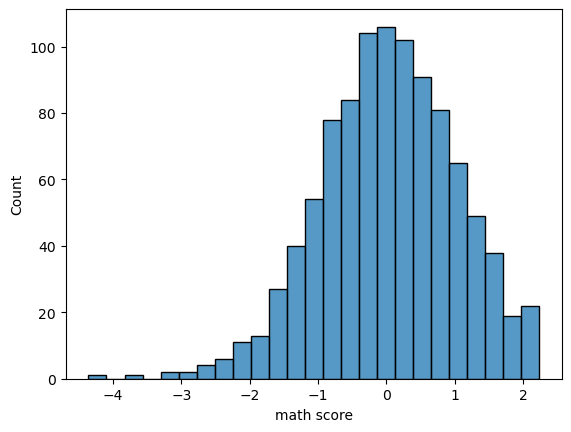

In [15]:
#step 3:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['math score'])
plt.show()


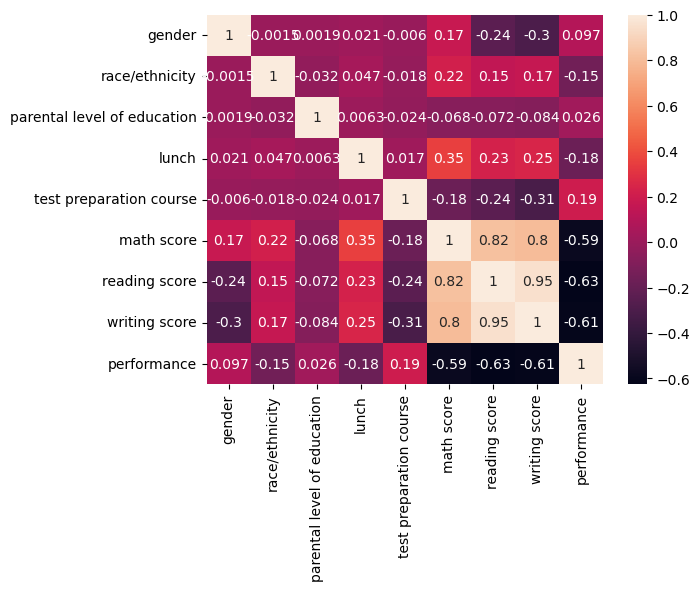

In [16]:
sns.heatmap(df.corr(), annot=True)
plt.show()

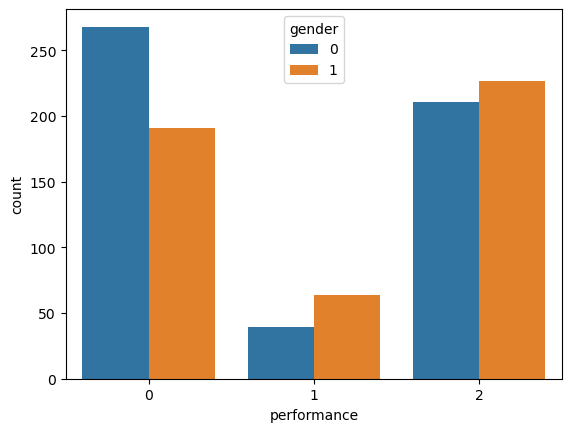

In [17]:
#gender vs performance
sns.countplot(x='performance', hue='gender', data=df)
plt.show()

In [18]:
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

In [20]:
#step5:machine learning models 
#split data
from sklearn.model_selection import train_test_split

X = df.drop('performance', axis=1)
y = df['performance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
#logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [22]:
#decision tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [23]:
#Rndom Foest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [24]:
#step 6: model evaluation
from sklearn.metrics import classification_report, confusion_matrix

print("Logistic Regression:\n", classification_report(y_test, y_pred_lr))
print("Decision Tree:\n", classification_report(y_test, y_pred_dt))
print("Random Forest:\n", classification_report(y_test, y_pred_rf))

Logistic Regression:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99        90
           1       1.00      0.93      0.96        27
           2       0.97      1.00      0.98        83

    accuracy                           0.98       200
   macro avg       0.99      0.97      0.98       200
weighted avg       0.99      0.98      0.98       200

Decision Tree:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        83

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        27
           2       1.

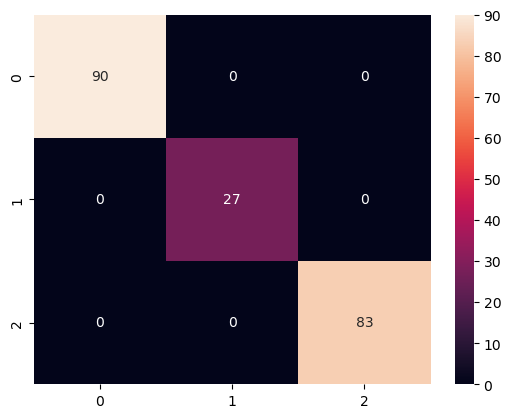

In [25]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True)
plt.show()